# 🥉 도장 1: 택시 운전 AI — FrozenLake 코드를 재활용해봅시다!

**난이도**: 🥉 쉬움 (20-30분)

**핵심 메시지**: Q-Learning 코드는 **재사용 가능**합니다! FrozenLake에서 쓴 코드를 복사해서 `env`만 바꾸면 완전히 다른 게임도 풀 수 있습니다.

**Taxi-v3 환경**:
- 500개 상태, 6개 행동 (남/북/동/서/태우기/내리기)
- 승객을 태우고 목적지까지 데려다주면 성공!

---

## 셀 1 — 라이브러리 임포트

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import random
from IPython.display import clear_output
import time

print('라이브러리 임포트 완료!')

라이브러리 임포트 완료!


## 셀 2 — train_q_learning 함수 정의

오전 수업에서 만든 Q-Learning 학습 함수입니다. **FrozenLake에서도 사용한 바로 그 함수!**

빈칸을 채워서 완성하세요.

In [2]:
def train_q_learning(env, n_episodes=5000, alpha=0.1, gamma=0.99,
                     epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995):
    """
    Q-Learning 학습 함수 (FrozenLake와 동일한 코드!)
    """
    # 상태 수와 행동 수 가져오기
    n_states = env.observation_space.n    # .n으로 상태 수 가져오기
    n_actions = env.action_space.n                   # action_space의 행동 수

    # Q-테이블 초기화
    q_table = np.zeros((n_states, n_actions))

    epsilon = epsilon_start
    episode_rewards = []

    for ep in range(n_episodes):
        state, _ = env.reset()  # 환경 초기화
        total_reward = 0

        for step in range(200):
            # epsilon-greedy 행동 선택
            if random.uniform(0, 1) < epsilon:
                action = env.action_space.sample() # 탐험 (exploration)
            else:
                action = np.argmax(q_table[state, :]) # 활용 (exploitation)

            # 환경 실행
            next_state, reward, terminated, truncated, _ = env.step(action)

            # Q-테이블 업데이트 (벨만 방정식)
            q_table[state, action] = q_table[state, action] + alpha * (reward + gamma * np.max(q_table[next_state, :]) - q_table[state, action])

            total_reward += reward
            state = next_state

            if terminated or truncated:
                break

        # epsilon 감소
        epsilon = max(epsilon_end, epsilon * epsilon_decay)
        episode_rewards.append(total_reward)

    return q_table, episode_rewards


print('train_q_learning 함수 정의 완료!')

train_q_learning 함수 정의 완료!


## 셀 3 — 환경 탐색

Taxi-v3 환경을 만들어서 구조를 살펴봅시다.

In [3]:
# 환경 생성
env = gym.make('Taxi-v3', render_mode='ansi')  # Taxi-v3

# 환경 기본 정보 확인
print('=== Taxi-v3 환경 정보 ===')
print(f'상태 수: {env.observation_space.n}')  # 500개 상태
print(f'행동 수: {env.action_space.n}')       # 6개 행동
print()

print('행동 의미:')
print('  0 = 남쪽 이동')
print('  1 = 북쪽 이동')
print('  2 = 동쪽 이동')
print('  3 = 서쪽 이동')
print('  4 = 승객 태우기 (Pickup)')
print('  5 = 승객 내리기 (Dropoff)')
print()

# 초기 상태 출력
state, info = env.reset(seed=42)
print(f'초기 상태 번호: {state}')
print()
print('초기 맵:')
print(env.render())

=== Taxi-v3 환경 정보 ===
상태 수: 500
행동 수: 6

행동 의미:
  0 = 남쪽 이동
  1 = 북쪽 이동
  2 = 동쪽 이동
  3 = 서쪽 이동
  4 = 승객 태우기 (Pickup)
  5 = 승객 내리기 (Dropoff)

초기 상태 번호: 386

초기 맵:
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




## 셀 4 — Q-Table 초기화 (크기 확인)

FrozenLake는 `np.zeros((16, 4))`였습니다. Taxi-v3는?

In [4]:
# Q-Table 크기 확인
q_table_test = np.zeros((env.observation_space.n, env.action_space.n))

print(f'Q-Table 크기: {q_table_test.shape}')
print(f'총 Q값 수: {q_table_test.size}')
print()
print('FrozenLake 대비 Q-Table이 훨씬 크지만, 코드는 동일합니다!')

Q-Table 크기: (500, 6)
총 Q값 수: 3000

FrozenLake 대비 Q-Table이 훨씬 크지만, 코드는 동일합니다!


## 셀 5 — Q-Learning 학습 실행

FrozenLake와 **완전히 동일한 함수**를 사용합니다. env만 바뀌었을 뿐!

In [5]:
# 학습 환경 생성
train_env = gym.make('Taxi-v3')  # Taxi-v3

# Q-Learning 학습 실행
print('학습 시작! (5000 에피소드)')
print('...')

q_table, rewards = train_q_learning(
    train_env, n_episodes=5000, alpha=0.1, gamma=0.99,
    epsilon_start=1.0, epsilon_end=0.01, epsilon_decay=0.995
)

print(f'학습 완료!')
print(f'마지막 100 에피소드 평균 보상: {np.mean(rewards[-100:]):.1f}')

학습 시작! (5000 에피소드)
...
학습 완료!
마지막 100 에피소드 평균 보상: 7.5


## 셀 6 — 학습 곡선 시각화

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/u

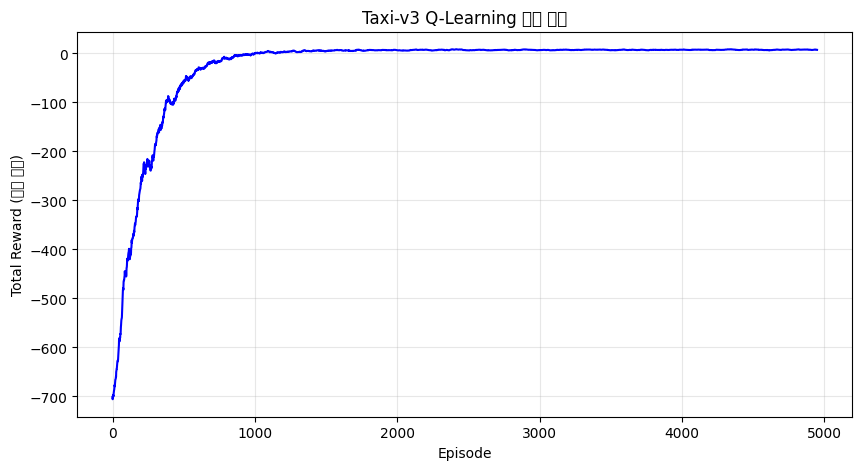

최종 100 에피소드 평균: 7.5


In [6]:
# 이동 평균 계산 함수
def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(moving_average(rewards, window=50), color='blue')  # window=50
plt.xlabel('Episode')
plt.ylabel('Total Reward (이동 평균)')
plt.title('Taxi-v3 Q-Learning 학습 곡선')
plt.grid(True, alpha=0.3)
plt.show()

print(f'최종 100 에피소드 평균: {np.mean(rewards[-100:]):.1f}')

## 셀 7 — 학습된 에이전트 테스트

학습된 Q-Table로 10번 플레이해서 평균 보상을 확인합니다.

In [7]:
# 테스트 환경
test_env = gym.make('Taxi-v3', render_mode='ansi')

test_rewards = []
action_names = ['남', '북', '동', '서', '태우기', '내리기']

for ep in range(10):
    state, _ = test_env.reset()
    total_reward = 0
    done = False
    steps = 0

    while not done and steps < 200:
        action = np.argmax(q_table[state])  # argmax로 최선의 행동 선택
        next_state, reward, terminated, truncated, _ = test_env.step(action)
        total_reward += reward
        state = next_state
        done = terminated or truncated
        steps += 1

    test_rewards.append(total_reward)
    print(f'에피소드 {ep+1:2d}: {steps:3d}스텝, 보상 = {total_reward}')

avg_reward = np.mean(test_rewards)
print(f'\n평균 보상: {avg_reward:.1f}')

에피소드  1:  14스텝, 보상 = 7
에피소드  2:  13스텝, 보상 = 8
에피소드  3:  12스텝, 보상 = 9
에피소드  4:  16스텝, 보상 = 5
에피소드  5:  14스텝, 보상 = 7
에피소드  6:  11스텝, 보상 = 10
에피소드  7:  13스텝, 보상 = 8
에피소드  8:  14스텝, 보상 = 7
에피소드  9:  15스텝, 보상 = 6
에피소드 10:  11스텝, 보상 = 10

평균 보상: 7.7


## 셀 8 — 택시 플레이 시연

학습된 택시가 어떻게 운전하는지 직접 눈으로 확인!

In [8]:
# 한 에피소드 시연
demo_env = gym.make('Taxi-v3', render_mode='ansi')  # Taxi-v3
state, _ = demo_env.reset(seed=42)

print('=== 학습된 택시 AI 시연 ===')
print(demo_env.render())

total_reward = 0
for step in range(50):
    action = np.argmax(q_table[state])
    next_state, reward, terminated, truncated, _ = demo_env.step(action)
    total_reward += reward

    print(f'Step {step+1:2d}: {action_names[action]} | 보상={reward:+d} | 누적={total_reward}')
    print(demo_env.render())

    state = next_state
    if terminated or truncated:
        break

print(f'\n총 {step+1}스텝, 총 보상: {total_reward}')

=== 학습된 택시 AI 시연 ===
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Step  1: 북 | 보상=-1 | 누적=-1
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

Step  2: 북 | 보상=-1 | 누적=-2
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

Step  3: 북 | 보상=-1 | 누적=-3
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (North)

Step  4: 태우기 | 보상=-1 | 누적=-4
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Pickup)

Step  5: 남 | 보상=-1 | 누적=-5
+---------+
|R: | : :G|
| : | : :_|
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Step  6: 서 | 보상=-1 | 누적=-6
+---------+
|R: | : :G|
| : | :_: |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (West)

Step  7: 남 | 보상=-1 | 누적=-7
+---------+
|R: | : :G|
| : | : : |
| : : :_: |
| | : | : |
|Y| : |B: |
+---------+
  (South)

Step  8: 서 | 보상=-1 | 누적=-8
+---------

## ✅ 도장 획득 체크!

평균 보상이 7 이상이면 🥉 도장을 획득합니다!

In [9]:
# 도장 체크
if avg_reward >= 7:
    print("✅ 통과!")
else:
    print("⚠️ 아직 부족합니다. 에피소드를 늘리거나 하이퍼파라미터를 조정해보세요.")

print('=' * 50)
print('🥉 도장 1 획득! 택시 운전 AI 완성!')
print('=' * 50)
print()
print(f'평균 보상: {avg_reward:.1f}')
print()
print('핵심 배운 점:')
print('  Q-Learning 코드는 재사용 가능!')
print('  FrozenLake 코드에서 env 이름만 바꾸면 Taxi도 학습됨!')
print('  상태 수/행동 수가 달라도 알고리즘은 동일!')
print()
print('다음 도장: 🥈 절벽 회피 AI (보상 설계의 힘!)')

✅ 통과!
🥉 도장 1 획득! 택시 운전 AI 완성!

평균 보상: 7.7

핵심 배운 점:
  Q-Learning 코드는 재사용 가능!
  FrozenLake 코드에서 env 이름만 바꾸면 Taxi도 학습됨!
  상태 수/행동 수가 달라도 알고리즘은 동일!

다음 도장: 🥈 절벽 회피 AI (보상 설계의 힘!)
